In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
SEED = 42
print('Libraries loaded')

Libraries loaded


In [ ]:
#-----Load the Dataset-----
df=pd.read_csv('/content/drive/MyDrive/Data/german_credit_data - german_credit_data.csv')
#-----DATA------
print(f'{'-'*5} THE DETAILS OF THE DATASET {'-'*5}\n')
print(f'The shape of dataset: {df.shape}\n')
print(f'The Column names & datatypes:\n{df.dtypes}\n')
print(f'The first 5 rows of this dataset:\n{df.head()}\n')
print(f'The missing values per column:\n{df.isnull().sum()}\n')
print(f'Duplicate Rows: {df.duplicated().sum()}\n')
print('Summary Statistics:\n')
display(df.describe().T.round(2))
print()
display(df.describe(include='object').T)
print()
#Complete Data Validation Check
print(f'{"-"*5} Data Validation {"-"*5}\n')
for col in df.columns:
  print(f'Column: {col}  |  Dtype: {df[col].dtype}')
  print(f'  Unique values ({df[col].nunique()}): {df[col].unique()[:10]}')
  if df[col].dtype == 'object':
#For categorical columns - check if any numeric values exist
    invalid = df[col].apply(lambda x: str(x).replace('.','').isdigit()).sum()
    print(f'  Numeric values found in text column: {invalid}')
  else:
# For numerical columns - check if any non-numeric values exist
    invalid = pd.to_numeric(df[col], errors='coerce').isna().sum()
    print(f'  Non-numeric values found in number column: {invalid}')
    print()
#Target distribution - checking for class imbalance
print(f'Target column distribution:\n{df["Risk"].value_counts()}\n')
print('NOTE: Target Data is slightly imbalanced (60.4% good,39.6(~40)% bad).\n')
print('This will be addressed during model training using class balancing techniques.\n')

----- THE DETAILS OF THE DATASET -----

The shape of dataset: (1000, 10)

The Column names & datatypes:
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

The first 5 rows of this dataset:
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   56    male    1     own          little         moderate           6745   
1   69  female    2    free        moderate         moderate          10437   
2   46    male    3     own      quite rich           little           9763   
3   32  female    1     own        moderate           little          18964   
4   60    male    2     own        moderate           little          17650   

   Duration              Purpose  Risk  
0        22                  car  good  
1        70         

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,46.25,16.29,18.0,33.00,46.0,60.25,74.0
Job,1000.0,1.31,0.90,0.0,1.00,1.0,2.00,3.0
Credit amount,1000.0,9943.91,5626.48,298.0,5021.25,9814.0,14785.50,19893.0
Duration,1000.0,36.81,19.33,4.0,21.00,36.0,53.00,71.0


,count,unique,top,freq
Sex,1000,2,male,523
Housing,1000,3,own,589
Saving accounts,915,4,little,412
Checking account,905,3,little,505
Purpose,1000,8,car,289
Risk,1000,2,good,604



----- Data Validation -----

Column: Age  |  Dtype: int64
  Unique values (57): [56 69 46 32 60 25 38 36 40 28]
  Non-numeric values found in number column: 0

Column: Sex  |  Dtype: object
  Unique values (2): ['male' 'female']
  Numeric values found in text column: 0

Column: Job  |  Dtype: int64
  Unique values (4): [1 2 3 0]
  Non-numeric values found in number column: 0

Column: Housing  |  Dtype: object
  Unique values (3): ['own' 'free' 'rent']
  Numeric values found in text column: 0

Column: Saving accounts  |  Dtype: object
  Unique values (4): ['little' 'moderate' 'quite rich' nan 'rich']
  Numeric values found in text column: 0

Column: Checking account  |  Dtype: object
  Unique values (3): ['moderate' 'little' 'rich' nan]
  Numeric values found in text column: 0

Column: Credit amount  |  Dtype: int64
  Unique values (982): [ 6745 10437  9763 18964 17650  7597 14499 15129 14307 12307]
  Non-numeric values found in number column: 0

Column: Duration  |  Dtype: int64
  Uni

----- Exploratory Data Analysis -----



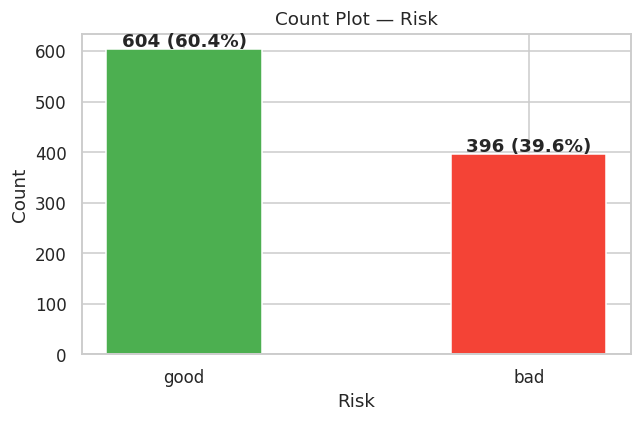

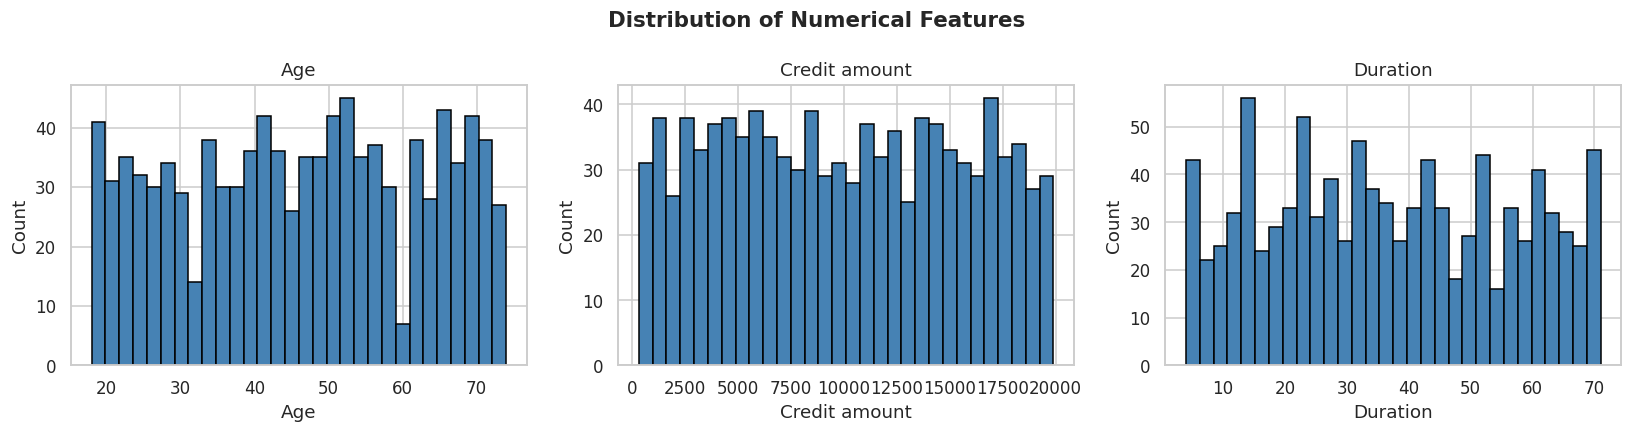

📊 Observation: Check if any feature is heavily skewed (one-sided shape)


In [ ]:
#----- EDA -----
print(f'{"-"*5} Exploratory Data Analysis {"-"*5}\n')
#Count plot of the target variable (Risk)
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Risk'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#4CAF50','#F44336'], width=0.45)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

ax.set_title('Count Plot — Risk')
ax.set_xlabel('Risk'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

#Numerical columns
num_cols = ['Age', 'Credit amount', 'Duration']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()
print("📊 Observation: Check if any feature is heavily skewed (one-sided shape)")

Box plots of feature distributions by risk category



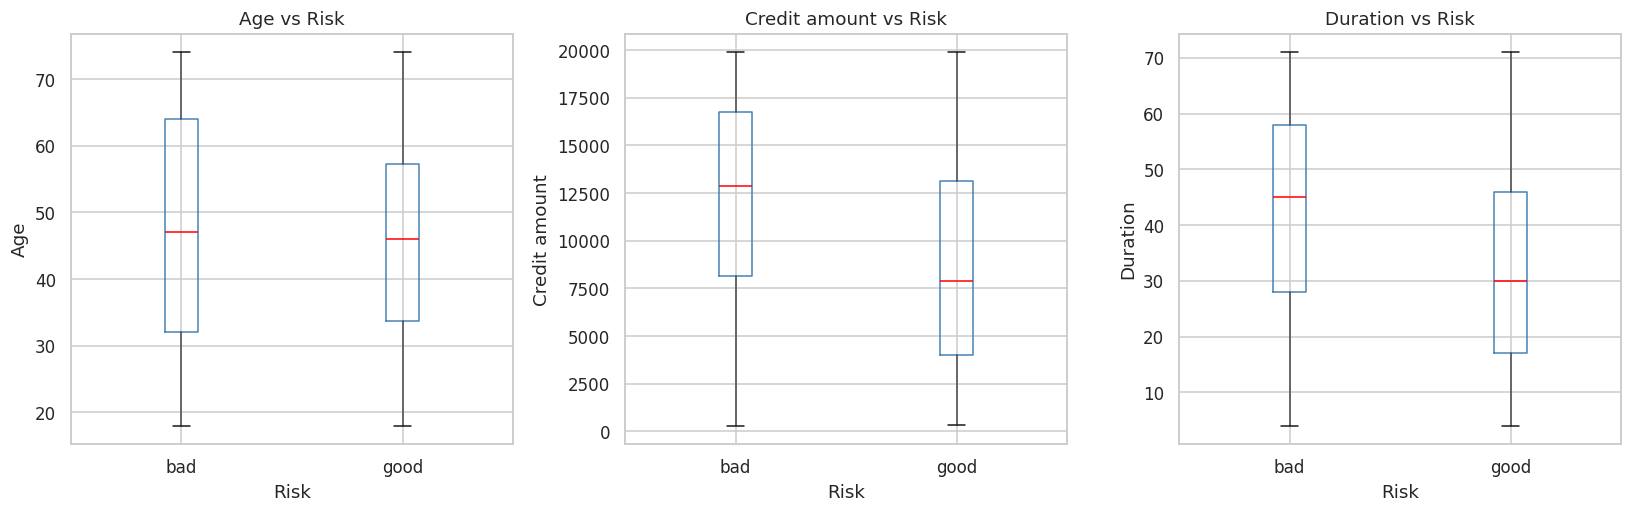


Correlation between numerical features:


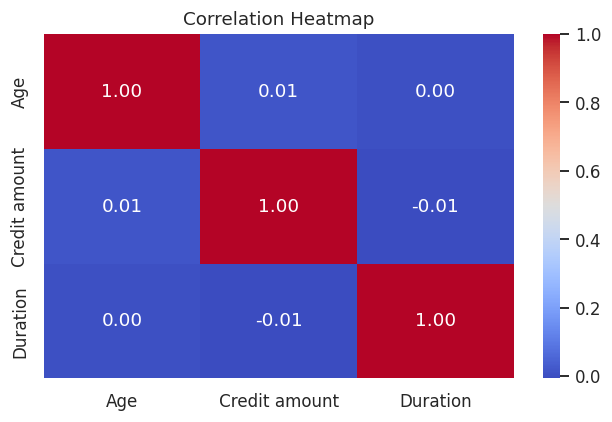

📊 Observation: Values close to 1 or -1 mean strong relationship between features


In [ ]:
# Boxplots - numerical features vs Risk
print('Box plots of feature distributions by risk category\n')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Numerical Features vs Risk', fontsize=14, fontweight='bold')
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Risk', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    axes[i].set_title(f'{col} vs Risk')
    axes[i].set_xlabel('Risk')
    axes[i].set_ylabel(col)
plt.suptitle('')
plt.tight_layout()
plt.show()
# Correlation heatmap (numerical only)
print("\nCorrelation between numerical features:")
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
print("📊 Observation: Values close to 1 or -1 mean strong relationship between features")

The additional insightful visualizations



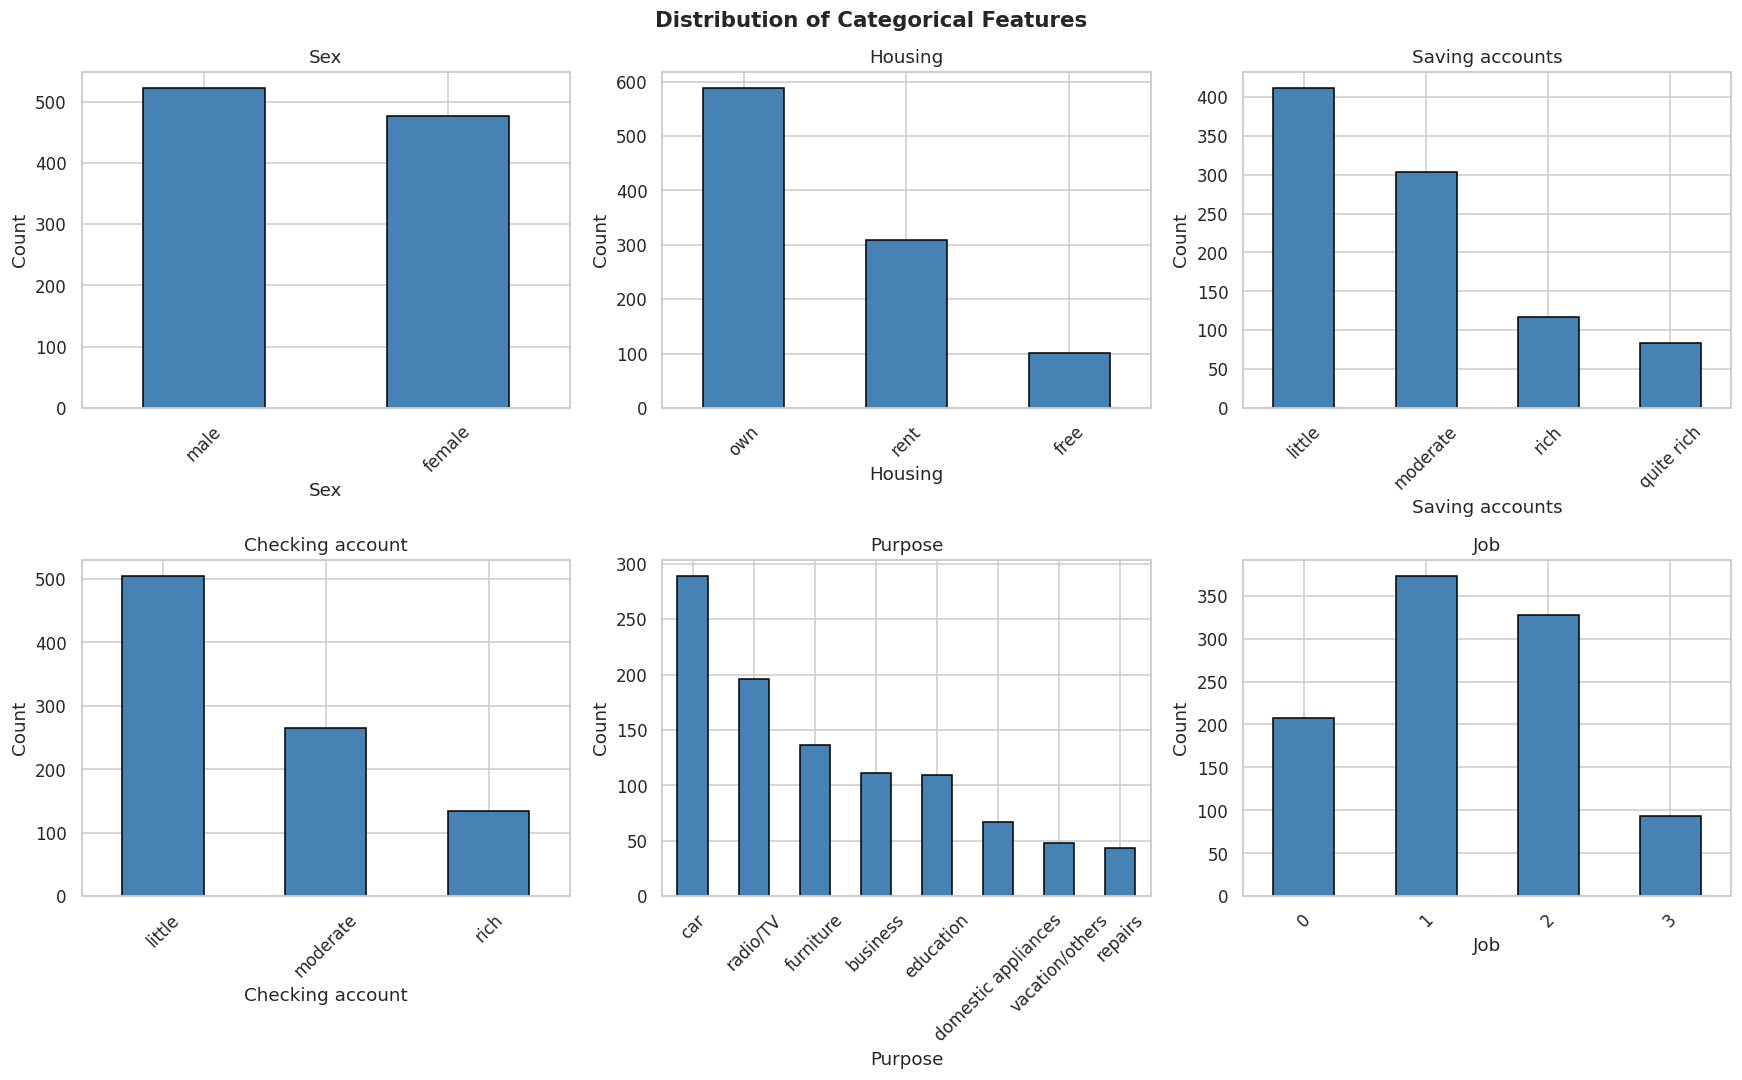

📊 Observation: Check which categories dominate in each feature


In [ ]:
#Additional insightful visualizations
print('The additional insightful visualizations\n')
#1.Categorical columns
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Job']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Categorical Features', fontsize=14, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if col == 'Job':
        df[col].value_counts().reindex([0,1,2,3]).plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    else:
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print("📊 Observation: Check which categories dominate in each feature")


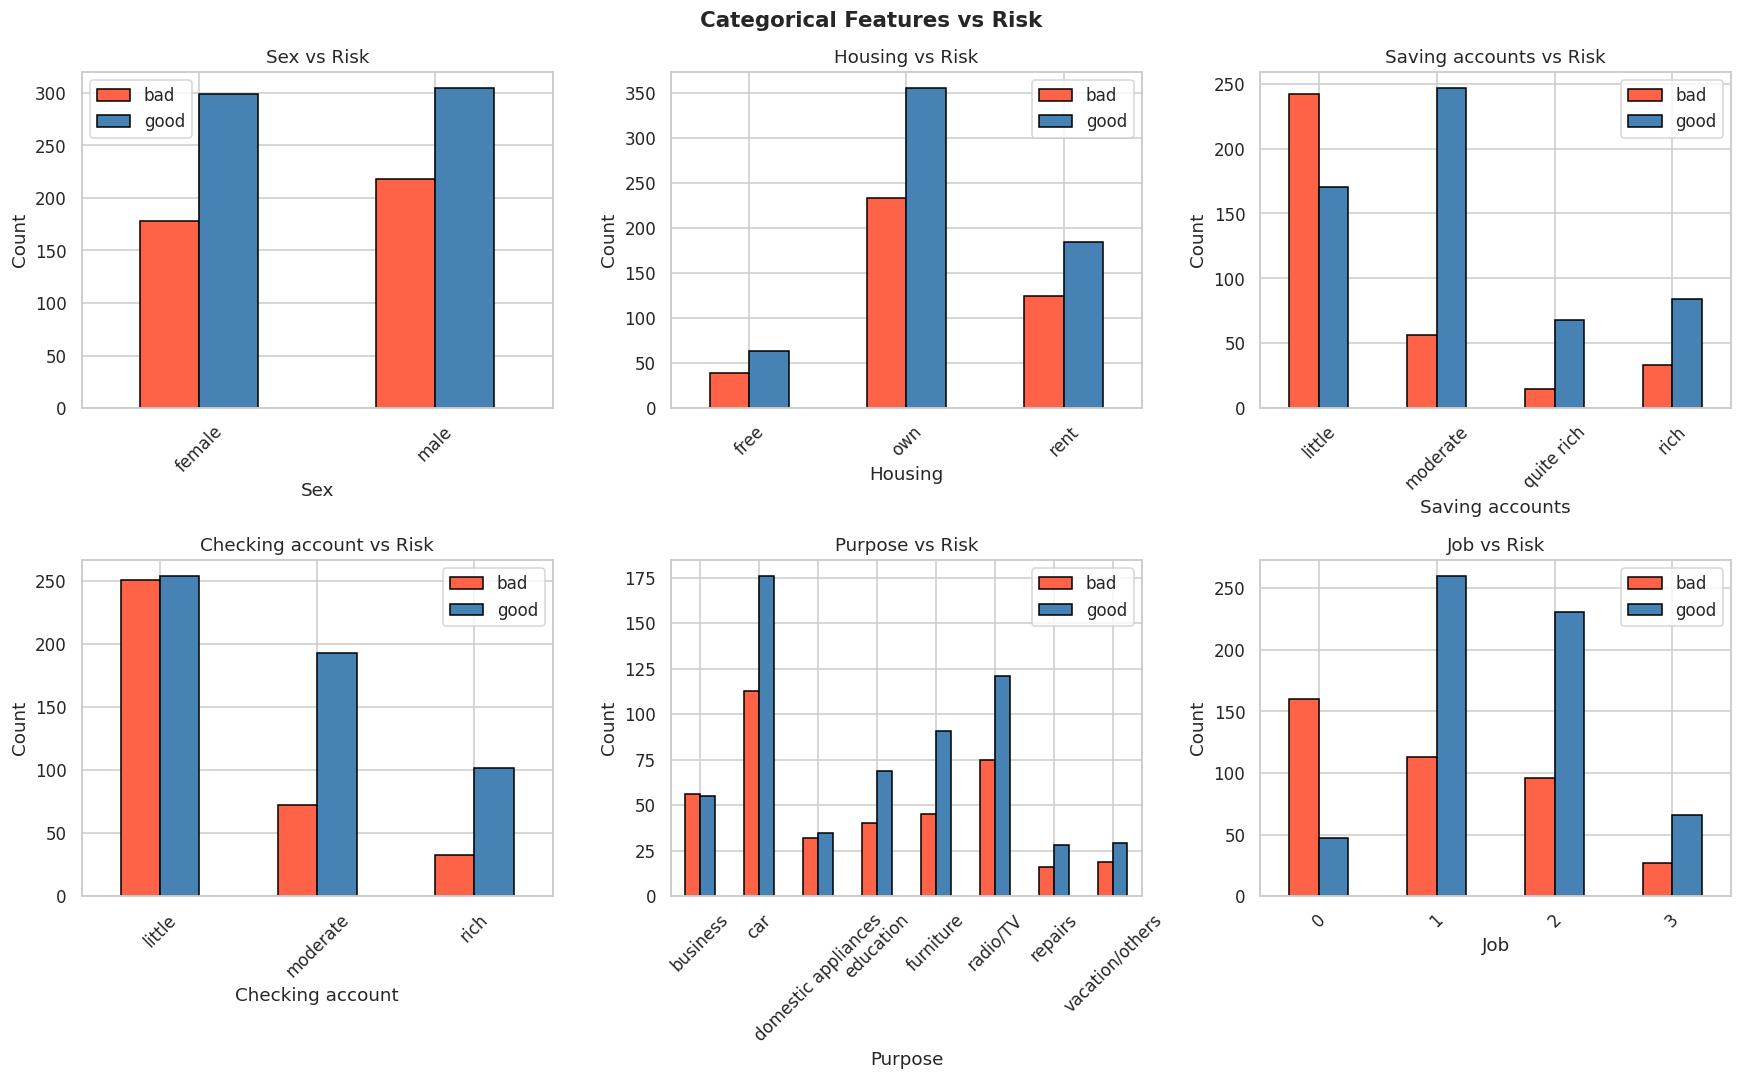

📊 Observation: Look for categories where 'bad' risk is noticeably higher


In [ ]:
#How each categorical feature relates to Risk
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Features vs Risk', fontsize=14, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    risk_counts = df.groupby([col, 'Risk']).size().unstack(fill_value=0)
    risk_counts.plot(kind='bar', ax=axes[i], color=['tomato', 'steelblue'], edgecolor='black')
    axes[i].set_title(f'{col} vs Risk')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['bad', 'good'])
plt.tight_layout()
plt.show()
print("📊 Observation: Look for categories where 'bad' risk is noticeably higher")

In [ ]:
#----- DATA PREPROCESSING -----
print(f'{"-"*5} Handling Missing Values {"-"*5}\n')

# Before filling
print("Missing values BEFORE filling:")
print(df[['Saving accounts', 'Checking account']].isnull().sum())

# Fill with 'unknown' category
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')
'''
JUSTIFICATION: Missing values are filled with 'unknown' because
the absence of an account is itself meaningful information,
not a random missing value. Replacing with mode would distort
the relationship between account status and credit risk.
'''
# After filling
print("\nMissing values AFTER filling:")
print(df[['Saving accounts', 'Checking account']].isnull().sum())

# Verify new category appeared
print("\nNew unique values in Saving accounts:")
print(df['Saving accounts'].unique())

print("\nNew unique values in Checking account:")
print(df['Checking account'].unique())

#Encoding
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
# Target encoding — Risk: good=0, bad=1
df_encoded['Risk'] = df_encoded['Risk'].map({'good': 0, 'bad': 1})
print("Target Encoding — Risk:")
print(df_encoded['Risk'].value_counts().to_string())

# Label Encoding for ordinal columns
le = LabelEncoder()
ordinal_cols = ['Saving accounts', 'Checking account']
for col in ordinal_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f'\nLabel Encoded: {col}')
    print(df_encoded[col].value_counts().to_string())

# One-Hot Encoding for nominal columns
nominal_cols = ['Sex', 'Housing', 'Purpose']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=False, dtype=int)
print(f'\nShape after encoding: {df_encoded.shape}')
print('\nColumns:', df_encoded.columns.tolist())

#SCALING
scaler = StandardScaler()
num_cols = ['Age', 'Credit amount', 'Duration']

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
print("Numerical features after scaling:")
display(df_encoded[num_cols].describe().round(2))

# ----- TRAIN-TEST SPLIT -----
X = df_encoded.drop(columns='Risk')
y = df_encoded['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')
print(f'\nClass distribution in y_train:')
print(y_train.value_counts().to_string())
print(f'\nClass distribution in y_test:')
print(y_test.value_counts().to_string())

# ----- FEATURE ENGINEERING -----

# Feature 1: Credit_to_Duration_Ratio
# Justification: Captures monthly repayment burden.
# High ratio = large instalments relative to loan length = higher financial stress
df_encoded['Credit_to_Duration_Ratio'] = (df['Credit amount'] / df['Duration']).round(2)

# Feature 2: Age_Group
# Justification: Raw age is linear but credit behaviour differs across life stages.
# Buckets capture non-linear patterns better than a continuous variable
df_encoded['Age_Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 50, df['Age'].max() + 1],
    labels=['18-25', '26-35', '36-50', '50+']
)
df_encoded = pd.get_dummies(df_encoded, columns=['Age_Group'], prefix='AgeGrp', dtype=int)

# Feature 3: High_Risk_Purpose
# Justification: Domain knowledge shows vacation/others/repairs/education
# have historically higher default rates. Binary flag isolates this signal.
HIGH_RISK = {'vacation', 'others', 'repairs', 'education'}
df_encoded['High_Risk_Purpose'] = df['Purpose'].isin(HIGH_RISK).astype(int)

print("New features preview:")
display(df_encoded[['Credit_to_Duration_Ratio', 'High_Risk_Purpose']].head())
print(f'\nFinal dataset shape: {df_encoded.shape}')

# Feature 4: Account_Stability
# Justification: Combines savings and checking account levels into a single
# financial health score. Higher score = more liquid assets = lower credit risk.
# Better than using two separate columns that measure similar things.

sav_map = {'unknown': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4}
chk_map = {'unknown': 0, 'little': 1, 'moderate': 2, 'rich': 3}

df_encoded['Account_Stability'] = (
    df['Saving accounts'].fillna('unknown').map(sav_map) +
    df['Checking account'].fillna('unknown').map(chk_map)
)

print("Account_Stability preview:")
print(df_encoded['Account_Stability'].value_counts().sort_index().to_string())

----- Handling Missing Values -----

Missing values BEFORE filling:
Saving accounts     85
Checking account    95
dtype: int64

Missing values AFTER filling:
Saving accounts     0
Checking account    0
dtype: int64

New unique values in Saving accounts:
['little' 'moderate' 'quite rich' 'unknown' 'rich']

New unique values in Checking account:
['moderate' 'little' 'rich' 'unknown']
Target Encoding — Risk:
Risk
0    604
1    396

Label Encoded: Saving accounts
Saving accounts
0    412
1    303
3    117
4     85
2     83

Label Encoded: Checking account
Checking account
0    505
1    265
2    135
3     95

Shape after encoding: (1000, 20)

Columns: ['Age', 'Job', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Risk', 'Sex_female', 'Sex_male', 'Housing_free', 'Housing_own', 'Housing_rent', 'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']
Numeric

,Age,Credit amount,Duration
count,1000.00,1000.00,1000.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.74,-1.72,-1.70
25%,-0.81,-0.88,-0.82
50%,-0.02,-0.02,-0.04
75%,0.86,0.86,0.84
max,1.70,1.77,1.77


X_train : (800, 19)
X_test  : (200, 19)
y_train : (800,)
y_test  : (200,)

Class distribution in y_train:
Risk
0    483
1    317

Class distribution in y_test:
Risk
0    121
1     79
New features preview:


,Credit_to_Duration_Ratio,High_Risk_Purpose
0,306.59,0
1,149.10,0
2,1220.38,0
3,270.91,0
4,1260.71,0



Final dataset shape: (1000, 26)
Account_Stability preview:
Account_Stability
0      6
1     89
2    251
3    273
4    209
5    116
6     43
7     13


In [ ]:
# Save cleaned dataset to Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/Data', exist_ok=True)

df.to_csv('/content/drive/MyDrive/Data/german_credit_data.csv', index=False)
X_train.to_csv('/content/drive/MyDrive/Data/X_train.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/Data/X_test.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/Data/y_train.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/Data/y_test.csv', index=False)

print("y_train.csv saved")
print("y_test.csv saved")
print('german_credit_data.csv saved to Drive')
print('X_train.csv saved to Drive')
print('X_test.csv saved to Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
y_train.csv saved
y_test.csv saved
german_credit_data.csv saved to Drive
X_train.csv saved to Drive
X_test.csv saved to Drive
